In [8]:
import shutil
from pathlib import Path
import matplotlib as mpl, importlib.util, pathlib, scienceplots  # noqa

pkg_file = importlib.util.find_spec("scienceplots").origin
styles_dir = pathlib.Path(pkg_file).parent / "styles"

user_stylelib = Path(mpl.get_configdir()) / "stylelib"
user_stylelib.mkdir(parents=True, exist_ok=True)

for f in styles_dir.glob("*.mplstyle"):
    shutil.copy2(f, user_stylelib / f.name)

mpl.style.reload_library()
print("'science' in mpl.style.available?", 'science' in mpl.style.available)

'science' in mpl.style.available? True


In [9]:
import sys
sys.path.insert(0, "/Users/yasin/code/CANDEL/")

from os.path import join, exists 

import numpy as np
from h5py import File


import sys, matplotlib as mpl, matplotlib.pyplot as plt
import scienceplots            # <-- registers the styles
import importlib
import pathlib

import matplotlib.pyplot as plt
# pkg_file = importlib.util.find_spec("scienceplots").origin
# pkg_dir = pathlib.Path(pkg_file).parent
# styles_dir = pkg_dir / "styles"
# plt.style.use(str(styles_dir / "science.mplstyle"))

import candel
from candel import plot_corner_from_hdf5, read_samples, read_gof
from utils import * 
from candel.util import radec_to_galactic
from candel.cosmography import Redshift2Distance
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
%load_ext autoreload
%autoreload 2

style_dir = pathlib.Path(importlib.util.find_spec("scienceplots").origin).parent / "styles"
plt.style.use("science")


#COLS = ["#87193d", "#1e42b9", "#d42a29", "#05dd6b", "#ee35d5"]

#COLS = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854"]
COLS = [  "#7570b3", "#d95f02", "#1b9e77", "#e7298a", "#66a61e"]
config_path = "/Users/yasin/code//CANDEL/scripts/runs/config.toml"
config = candel.load_config(config_path, )
root = join("/Users/yasin/code/CANDEL/", "results/", "")
print(root)

figures_folder = "/Users/yasin/Dropbox/Apps/Overleaf/Cluster Anisotropies !/Figures/"

results_folder = "short"

plt.rcParams.update({
    "font.size": 12,            # base font size
    "axes.titlesize": 16,       # title
    "axes.labelsize": 14,       # x/y labels
    "xtick.labelsize": 12,      # tick labels
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 18      # suptitle
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/yasin/code/CANDEL/results/


### Redshift distribution plot

In [10]:
config_path =  '/Users/yasin/code/CANDEL/tariq_notebooks/paper_Clusters/data.toml'
data = candel.pvdata.load_PV_dataframes(config_path)
model = candel.model.ClustersModel(config_path,)
model_kwargs = {'data':data,}

2025-11-14 14:59:12 loading 1 PV dataframes: ['Clusters']
2025-11-14 14:59:12 loading existing LOS data from /Users/yasin/code/CANDEL/data/Clusters/los_Clusters_Carrick2015.hdf5.
2025-11-14 14:59:12 initially loaded 312 clusters.
2025-11-14 14:59:12 converting clusters' redshifts to the CMB frame.
2025-11-14 14:59:12 removed 0 clusters, thus 312 remain.
2025-11-14 14:59:12 subtracting the mean logT from the data.
2025-11-14 14:59:12 setting the LOS radial grid from 0.1 to 1001 with 251 points.
2025-11-14 14:59:12 setting los_decay_scale to 5.0
2025-11-14 14:59:12 marginalising over 1 field realisations.


/Users/yasin/code/CANDEL/candel/pvdata/data.py:1426: RuntimeWarning: invalid value encountered in log10
  logY = np.log10(Y_arcmin2)


2025-11-14 14:59:12 precomputing Vext_per_pix data for nside = 1.
2025-11-14 14:59:12 precomputing Vext_radial_binned data with bin edges (comoving Mpc): [0, 250, 500, 1000].
2025-11-14 14:59:12 marginalizing eta with k_sigma = 5 and n_grid = 31 (if TFR).


[np.float64(1e-05), np.float64(0.08157662482886263), np.float64(0.16653208188137847), np.float64(0.25541783290740305), np.float64(0.34885570321455106), np.float64(0.44754859659659657)] [   0.  240.  480.  720.  960. 1200.]


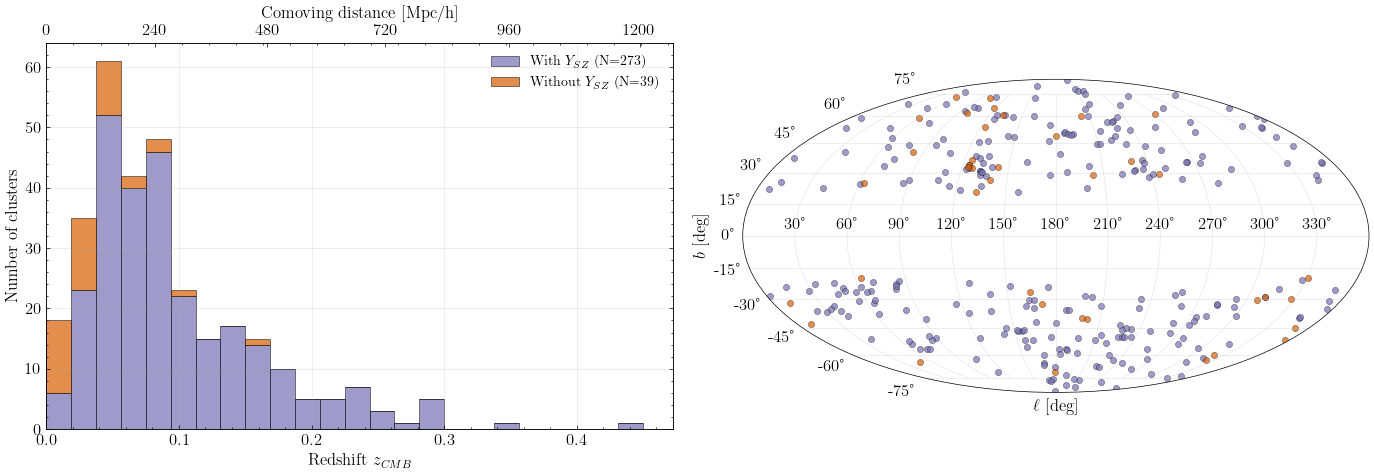

In [16]:

r2d = Redshift2Distance()

# Create figure with two subplots - one normal, one with Mollweide projection
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121)  # Left panel: regular histogram
ax2 = fig.add_subplot(122, projection='mollweide')  # Right panel: Mollweide

# Get data from PVDataFrame
zcmb = data.data['zcmb']
Y = data.data['Y']
RA = data.data['RA']
DEC = data.data['dec']

# Convert RA, DEC to galactic coordinates
ell, b = radec_to_galactic(RA, DEC)

# Split by Y_SZ availability
has_Y = Y > 0
no_Y = Y < 0

# Left panel: Stacked histogram showing both populations
bins = np.linspace(0, 0.45, 25)
counts_no_Y, bin_edges = np.histogram(zcmb[no_Y], bins=bins)
counts_has_Y, _ = np.histogram(zcmb[has_Y], bins=bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = bin_edges[1] - bin_edges[0]

ax1.bar(bin_centers, counts_has_Y, width=width, alpha=0.7, 
        label=f'With $Y_{{SZ}}$ (N={np.sum(has_Y)})', 
        color=COLS[0], edgecolor='black', linewidth=0.5)
ax1.bar(bin_centers, counts_no_Y, width=width, alpha=0.7, 
        bottom=counts_has_Y,
        label=f'Without $Y_{{SZ}}$ (N={np.sum(no_Y)})', 
        color=COLS[1], edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Redshift $z_{CMB}$', fontsize=12)
ax1.set_ylabel('Number of clusters', fontsize=12)
ax1.set_xlim(left=0.0)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Add secondary x-axis for comoving distance
ax1_top = ax1.twiny()
# Function to convert redshift to comoving distance in Mpc/h (h=1)
def z_to_dist(z):
    return r2d(z, h=1.0)

def dist_to_z(d):
    # Approximate inverse (for tick positioning)
    # Create a lookup for common distances
    z_test = np.linspace(1e-5, 0.5, 1000)
    d_test = r2d(z_test, h=1.0)
    return np.interp(d, d_test, z_test)

# Set the limits to match ax1
ax1_top.set_xlim(ax1.get_xlim())

# Get current x-axis limits in redshift
d_min, d_max = z_to_dist(np.array([1e-5, 0.5]))

# Create nice tick positions in comoving distance
d_ticks = np.linspace(0, int(d_max/200)*200, 6)  # Round to nice values
z_ticks = [dist_to_z(d) for d in d_ticks]

print(z_ticks, d_ticks)

ax1_top.set_xticks(z_ticks)
ax1_top.set_xticklabels([f'{int(d)}' for d in d_ticks])
ax1_top.set_xlabel('Comoving distance [Mpc/h]', fontsize=12)

# Right panel: Sky distribution in Mollweide projection (galactic coordinates)
# Convert galactic coordinates to radians, centered at 180 deg for Mollweide
# Mollweide projection expects longitude centered at 0 (which we'll label as 180)
ell_centered = np.where(ell > 180, ell - 360, ell)
ell_rad = np.deg2rad(ell_centered)
b_rad = np.deg2rad(b)

# Plot both populations
ax2.scatter(ell_rad[has_Y], b_rad[has_Y], s=20, alpha=0.7, 
            color=COLS[0], edgecolors='black', linewidths=0.3,
            label=f'With $Y_{{SZ}}$ (N={np.sum(has_Y)})')
ax2.scatter(ell_rad[no_Y], b_rad[no_Y], s=20, alpha=0.7, 
            color=COLS[1], edgecolors='black', linewidths=0.3,
            label=f'Without $Y_{{SZ}}$ (N={np.sum(no_Y)})')

ax2.set_xlabel('$\\ell$ [deg]', fontsize=12)
ax2.set_ylabel('$b$ [deg]', fontsize=12)

# Set custom tick labels to show 0-360 degrees
# Mollweide x-axis goes from -π to π, which we map to 0-360
tick_locs = np.array([-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150])
tick_labels = [(loc + 180) % 360 for loc in tick_locs]
ax2.set_xticks(np.deg2rad(tick_locs))
ax2.set_xticklabels([f'{int(label)}°' for label in tick_labels])

ax2.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(join(figures_folder, 'redshift.pdf'), dpi=300)

plt.show()




### Scaling relation plot

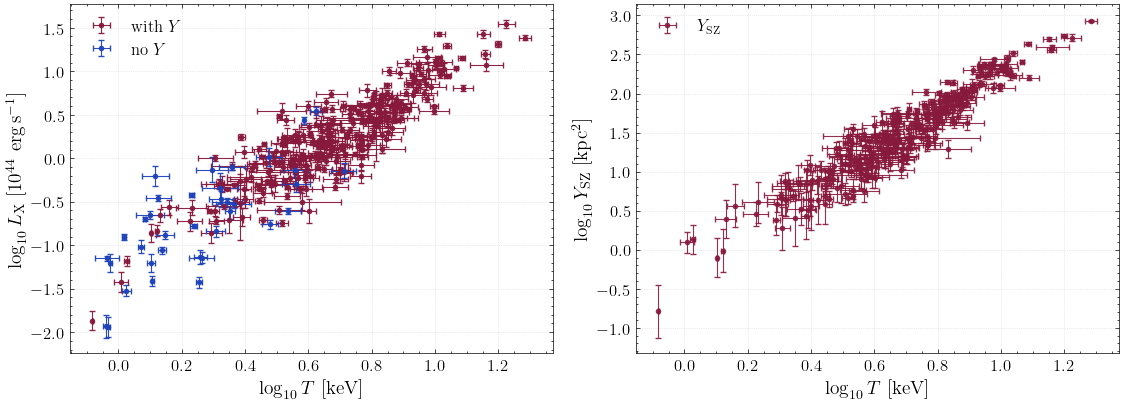

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# ---------------------------
# Load + base quantities
# ---------------------------
dtype = [
    ('Cluster', 'U32'), ('z', 'f8'), ('Glon', 'f8'), ('Glat', 'f8'),
    ('Offset', 'f8'), ('T', 'f8'), ('Tmax', 'f8'), ('Tmin', 'f8'),
    ('Lx', 'f8'), ('eL', 'f8'), ('NHtot', 'f8'), ('Metal', 'f8'),
    ('Met_max', 'f8'), ('Met_min', 'f8'), ('Y_arcmin2', 'f8'),
    ('e_Y', 'f8'), ('Y5r500', 'f8'), ('e_Y2', 'f8'), ('Y_nr_no_ksz', 'f8'),
    ('e_Y3', 'f8'), ('Y_nr_mmf', 'f8'), ('e_Y4', 'f8'), ('Y_nr_mf', 'f8'),
    ('e_Y5', 'f8'), ('Abs2MASS', 'f8'), ('BCG_Offset', 'f8'),
    ('Catalog', 'U32'), ('Analysed_by', 'U32')
]

data = np.genfromtxt('/Users/yasin/code/CANDEL/data/Clusters/ClustersData.txt',
                     dtype=dtype, skip_header=1)

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = data['z']
DA = cosmo.angular_diameter_distance(z).value  # [Mpc]

# ---------------------------
# Compute Y D_A^2 in kpc²
# ---------------------------
arcmin = np.pi / (180 * 60)        # radians per arcmin
arcmin2_to_sr = arcmin**2
Mpc_to_kpc = 1e3

Y_arcmin2 = data['Y_arcmin2']
e_Y = data['e_Y']
YDA2 = Y_arcmin2 * arcmin2_to_sr * (DA * Mpc_to_kpc)**2  # [kpc²]
hasY = np.isfinite(Y_arcmin2) & (Y_arcmin2 > 0)

# ---------------------------
# Logged quantities + errors
# ---------------------------
T = data['T']           # keV
Tmax = data['Tmax']
Tmin = data['Tmin']
Lx = data['Lx']         # in 1e44 erg/s
eL = data['eL']         # percent

pos_T = np.isfinite(T) & (T > 0)
pos_Lx = np.isfinite(Lx) & (Lx > 0)
pos_YDA2 = np.isfinite(YDA2) & (YDA2 > 0) & hasY

logT = np.log10(T)
logLx = np.log10(Lx)
logYDA2 = np.full_like(YDA2, np.nan, dtype=float)
logYDA2[pos_YDA2] = np.log10(YDA2[pos_YDA2])

log10e = np.log10(np.e)
dT = (Tmax - Tmin) / 2.0
e_logT = log10e * (dT / T)
e_logLx = log10e * (eL / 100.0)
e_logYDA2 = log10e * (e_Y / Y_arcmin2)

# ---------------------------
# Plotting
# ---------------------------
c_withY = "#87193d"
c_noY = "#1e42b9"

mask_Lx_withY = pos_T & pos_Lx & hasY
mask_Lx_withoutY = pos_T & pos_Lx & (~hasY)
mask_YDA2 = pos_YDA2 & np.isfinite(logT) & np.isfinite(e_logT) & np.isfinite(e_logYDA2)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharex=True)

# (1) Lx–T on the left
ax = axes[0]
ax.errorbar(
    logT[mask_Lx_withY], logLx[mask_Lx_withY],
    xerr=e_logT[mask_Lx_withY], yerr=e_logLx[mask_Lx_withY],
    fmt='o', ms=4, lw=0.8, capsize=2, mec='none', alpha=0.95,
    color=c_withY, label='with $Y$'
)
ax.errorbar(
    logT[mask_Lx_withoutY], logLx[mask_Lx_withoutY],
    xerr=e_logT[mask_Lx_withoutY], yerr=e_logLx[mask_Lx_withoutY],
    fmt='o', ms=4, lw=0.8, capsize=2, mec='none', alpha=0.95,
    color=c_noY, label='no $Y$'
)
ax.set_xlabel(r'$\log_{10} T\ \mathrm{[keV]}$')
ax.set_ylabel(r'$\log_{10} L_{\rm X}\ \mathrm{[10^{44}\ erg\,s^{-1}]}$')
ax.grid(True, ls=':', alpha=0.5)
ax.legend(frameon=False)

# (2) Y_SZ–T on the right
ax = axes[1]
ax.errorbar(
    logT[mask_YDA2], logYDA2[mask_YDA2],
    xerr=e_logT[mask_YDA2], yerr=e_logYDA2[mask_YDA2],
    fmt='o', ms=4, lw=0.8, capsize=2, mec='none', alpha=0.9,
    color=c_withY, label=r'$Y_{\mathrm{SZ}}$'
)
ax.set_xlabel(r'$\log_{10} T\ \mathrm{[keV]}$')
ax.set_ylabel(r'$\log_{10} Y_{\mathrm{SZ}}\ \mathrm{[kpc^2]}$')
ax.grid(True, ls=':', alpha=0.5)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(join(figures_folder, 'relations.pdf'), dpi=300)
plt.show()

### Results table

In [21]:
with open(join("/Users/yasin/code/CANDEL/scripts/runs", "tasks_0.txt")) as f:
    fnames = [line.strip().split(" ")[1] for line in f if line.strip()]
    fnames = [fname.replace(".toml", ".hdf5") for fname in fnames]
print(fnames)

['/Users/yasin/code/CANDEL/results/friday/Carrick2015_Clusters_noMNR_LTYT_hasY.hdf5', '/Users/yasin/code/CANDEL/results/friday/Carrick2015_Clusters_noMNR_LTYT_dipA_hasY.hdf5']


In [20]:
for fname in fnames:
    if 'Carrick2015' not in fname:
        continue
    print(fname.split("/")[-1].split(".hdf5")[0])
    gof = read_gof(fname, "logZ_harmonic")
    print(gof)


Carrick2015_Clusters_noMNR_LTYT_hasY
-1175.968623485146
Carrick2015_Clusters_noMNR_LTYT_dipA_hasY
-1175.2385082990165


In [19]:
# ===== CONFIG: stems -> pretty names (no numbering) =====
pretty_name_map = {
    "manticore_Clusters_noMNR_LTYT_hasY":                r"No flow or $H_0$ variation",
    "manticore_Clusters_noMNR_LTYT_dipVext_hasY":        r"$\mathbf{V}_{\rm ext}$ dipole",
    "manticore_Clusters_noMNR_LTYT_quadVext_hasY":       r"$\mathbf{V}_{\rm ext}$ quadrupole",
    "manticore_Clusters_noMNR_LTYT_pixVext_hasY":        r"$\mathbf{V}_{\rm ext}$ pixelised",
    "manticore_Clusters_noMNR_LTYT_radVext_hasY":        r"$\mathbf{V}_{\rm ext}$ radially varying dipole",
    "manticore_Clusters_noMNR_LTYT_dipA_hasY":           r"$H_0$ dipole",
    "manticore_Clusters_noMNR_LTYT_quadA_hasY":          r"$H_0$ quadrupole",
    "manticore_Clusters_noMNR_LTYT_pixA_hasY":           r"$H_0$ pixelised",
    "manticore_Clusters_noMNR_LTYT_dipVext_dipA_hasY":   r"$H_0$ dipole + $\mathbf{V}_{\rm ext}$ dipole",
}

row_order = [
    "manticore_Clusters_noMNR_LTYT_hasY",
    "manticore_Clusters_noMNR_LTYT_dipVext_hasY",
    "manticore_Clusters_noMNR_LTYT_quadVext_hasY",
    "manticore_Clusters_noMNR_LTYT_pixVext_hasY",
    "manticore_Clusters_noMNR_LTYT_radVext_hasY",
    "manticore_Clusters_noMNR_LTYT_dipA_hasY",
    "manticore_Clusters_noMNR_LTYT_quadA_hasY",
    "manticore_Clusters_noMNR_LTYT_pixA_hasY",
    "manticore_Clusters_noMNR_LTYT_dipVext_dipA_hasY",
]

# ===== collect stats from files =====
import os, math

def stem_from_fname(fname: str) -> str:
    return os.path.basename(fname).split(".hdf5")[0]

def safe_get(fname, key):
    try:
        return read_gof(fname, key)
    except Exception:
        return None

stats = {}
for fname in fnames:
    if "manticore" not in fname:
        continue
    stem = stem_from_fname(fname)
    if stem not in pretty_name_map:
        continue
    stats[stem] = {
        "lnZ_harmonic":     safe_get(fname, "lnZ_harmonic"),
        "err_lnZ_harmonic": safe_get(fname, "err_lnZ_harmonic"),
        "lnZ_laplace":      safe_get(fname, "lnZ_laplace"),
        "err_lnZ_laplace":  safe_get(fname, "err_lnZ_laplace"),
        "BIC":              safe_get(fname, "BIC"),
    }

# ----- baseline (reference is lnZ_harmonic of the baseline model) -----
baseline_stem = "manticore_Clusters_noMNR_LTYT_hasY"
zb  = stats[baseline_stem].get("lnZ_harmonic")
ezb = stats[baseline_stem].get("err_lnZ_harmonic")

# ===== helpers =====
def pm_two_dec(val, err=None):
    if val is None:
        return r"\textemdash"
    if err is None:
        return f"{val:.2f}"
    return f"{val:.2f} $\\pm$ {err:.2f}"

def quadrature(a, b):
    if a is None and b is None:
        return None
    a = 0.0 if a is None else a
    b = 0.0 if b is None else b
    return math.sqrt(a*a + b*b)

# ===== build LaTeX table (all referenced to baseline lnZ_harm) =====
header = r"""\begin{table}
\centering
\caption{Relative goodness-of-fit referenced to the baseline model (``No flow or $H_0$ variation''). We report $\Delta\ln Z_{\rm harm} \equiv \ln Z_{\rm harm}-\ln Z_{\rm harm}^{\rm (base)}$, $\Delta\ln Z_{\rm Laplace} \equiv \ln Z_{\rm Laplace}-\ln Z_{\rm harm}^{\rm (base)}$, and $\Delta\ln Z_{\rm BIC}$ where $\ln Z_{\rm BIC}\equiv -\tfrac{1}{2}\,{\rm BIC}$, also referenced to $\ln Z_{\rm harm}^{\rm (base)}$. Uncertainties are shown where available.}
\begin{tabular}{lccc}
\hline
Model & $\Delta\ln Z_{\rm harm}$ & $\Delta\ln Z_{\rm Laplace}$ & $\Delta\ln Z_{\rm BIC}$ \\
\hline
"""

rows = []
for stem in row_order:
    name = pretty_name_map.get(stem, stem.replace("_", r"\_"))
    s = stats.get(stem, {})

    # Δ lnZ_harm
    z  = s.get("lnZ_harmonic")
    ez = s.get("err_lnZ_harmonic")
    dlh  = (None if (z is None or zb is None) else (z - zb))
    sdlh = (None if (ez is None and ezb is None) else quadrature(ez, ezb))

    # Δ lnZ_Laplace (still referenced to baseline lnZ_harm)
    zl  = s.get("lnZ_laplace")
    ezl = s.get("err_lnZ_laplace")
    dll  = (None if (zl is None or zb is None) else (zl - zb))
    sdll = (None if (ezl is None and ezb is None) else quadrature(ezl, ezb))

    # Δ lnZ_BIC: lnZ_BIC = -BIC/2; reference to baseline lnZ_harm
    bic = s.get("BIC")
    lnZ_BIC = (None if bic is None else (-0.5 * bic))
    dlbic = (None if (lnZ_BIC is None or zb is None) else (lnZ_BIC - zb))
    # no quoted uncertainty for BIC -> show value only
    row = " & ".join([
        name,
        pm_two_dec(dlh,  sdlh),
        pm_two_dec(dll,  sdll),
        pm_two_dec(dlbic, None),
    ]) + r" \\"
    rows.append(row)

footer = r"""\hline
\end{tabular}
\label{tab:gof_relative_bic}
\end{table*}
"""

latex_table = header + "\n".join(rows) + "\n" + footer
print(latex_table)

KeyError: 'manticore_Clusters_noMNR_LTYT_hasY'

### Figure: Whole posterior

['/Users/yasin/code/CANDEL/results/short/manticore_LTYT_noMNR_nodipA_hasY.hdf5', '/Users/yasin/code/CANDEL/results/short/manticore_LTYT_noMNR_nodipA_dipVext_hasY.hdf5', '/Users/yasin/code/CANDEL/results/short/manticore_LTYT_noMNR_dipA_hasY.hdf5']
manticore_LTYT_noMNR_nodipA_hasY.hdf5: A_LT, A_YT, B_LT, B_YT, R_dist_emp, alpha, beta, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v
manticore_LTYT_noMNR_nodipA_dipVext_hasY.hdf5: A_LT, A_YT, B_LT, B_YT, R_dist_emp, Vext, Vext_b, Vext_ell, Vext_mag, alpha, beta, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v
manticore_LTYT_noMNR_dipA_hasY.hdf5: A_LT, A_YT, B_LT, B_YT, R_dist_emp, alpha, beta, dH_over_H_dipole, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v, zeropoint_dipole_b, zeropoint_dipole_ell
Removed no burn in
Removed no burn in
Removed no burn in


/Users/yasin/code/CANDEL/candel/util.py:778: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


2025-11-11 12:04:47 [INFO] Saving GetDist triangle plot to: /Users/yasin/Downloads/main_posterior.pdf


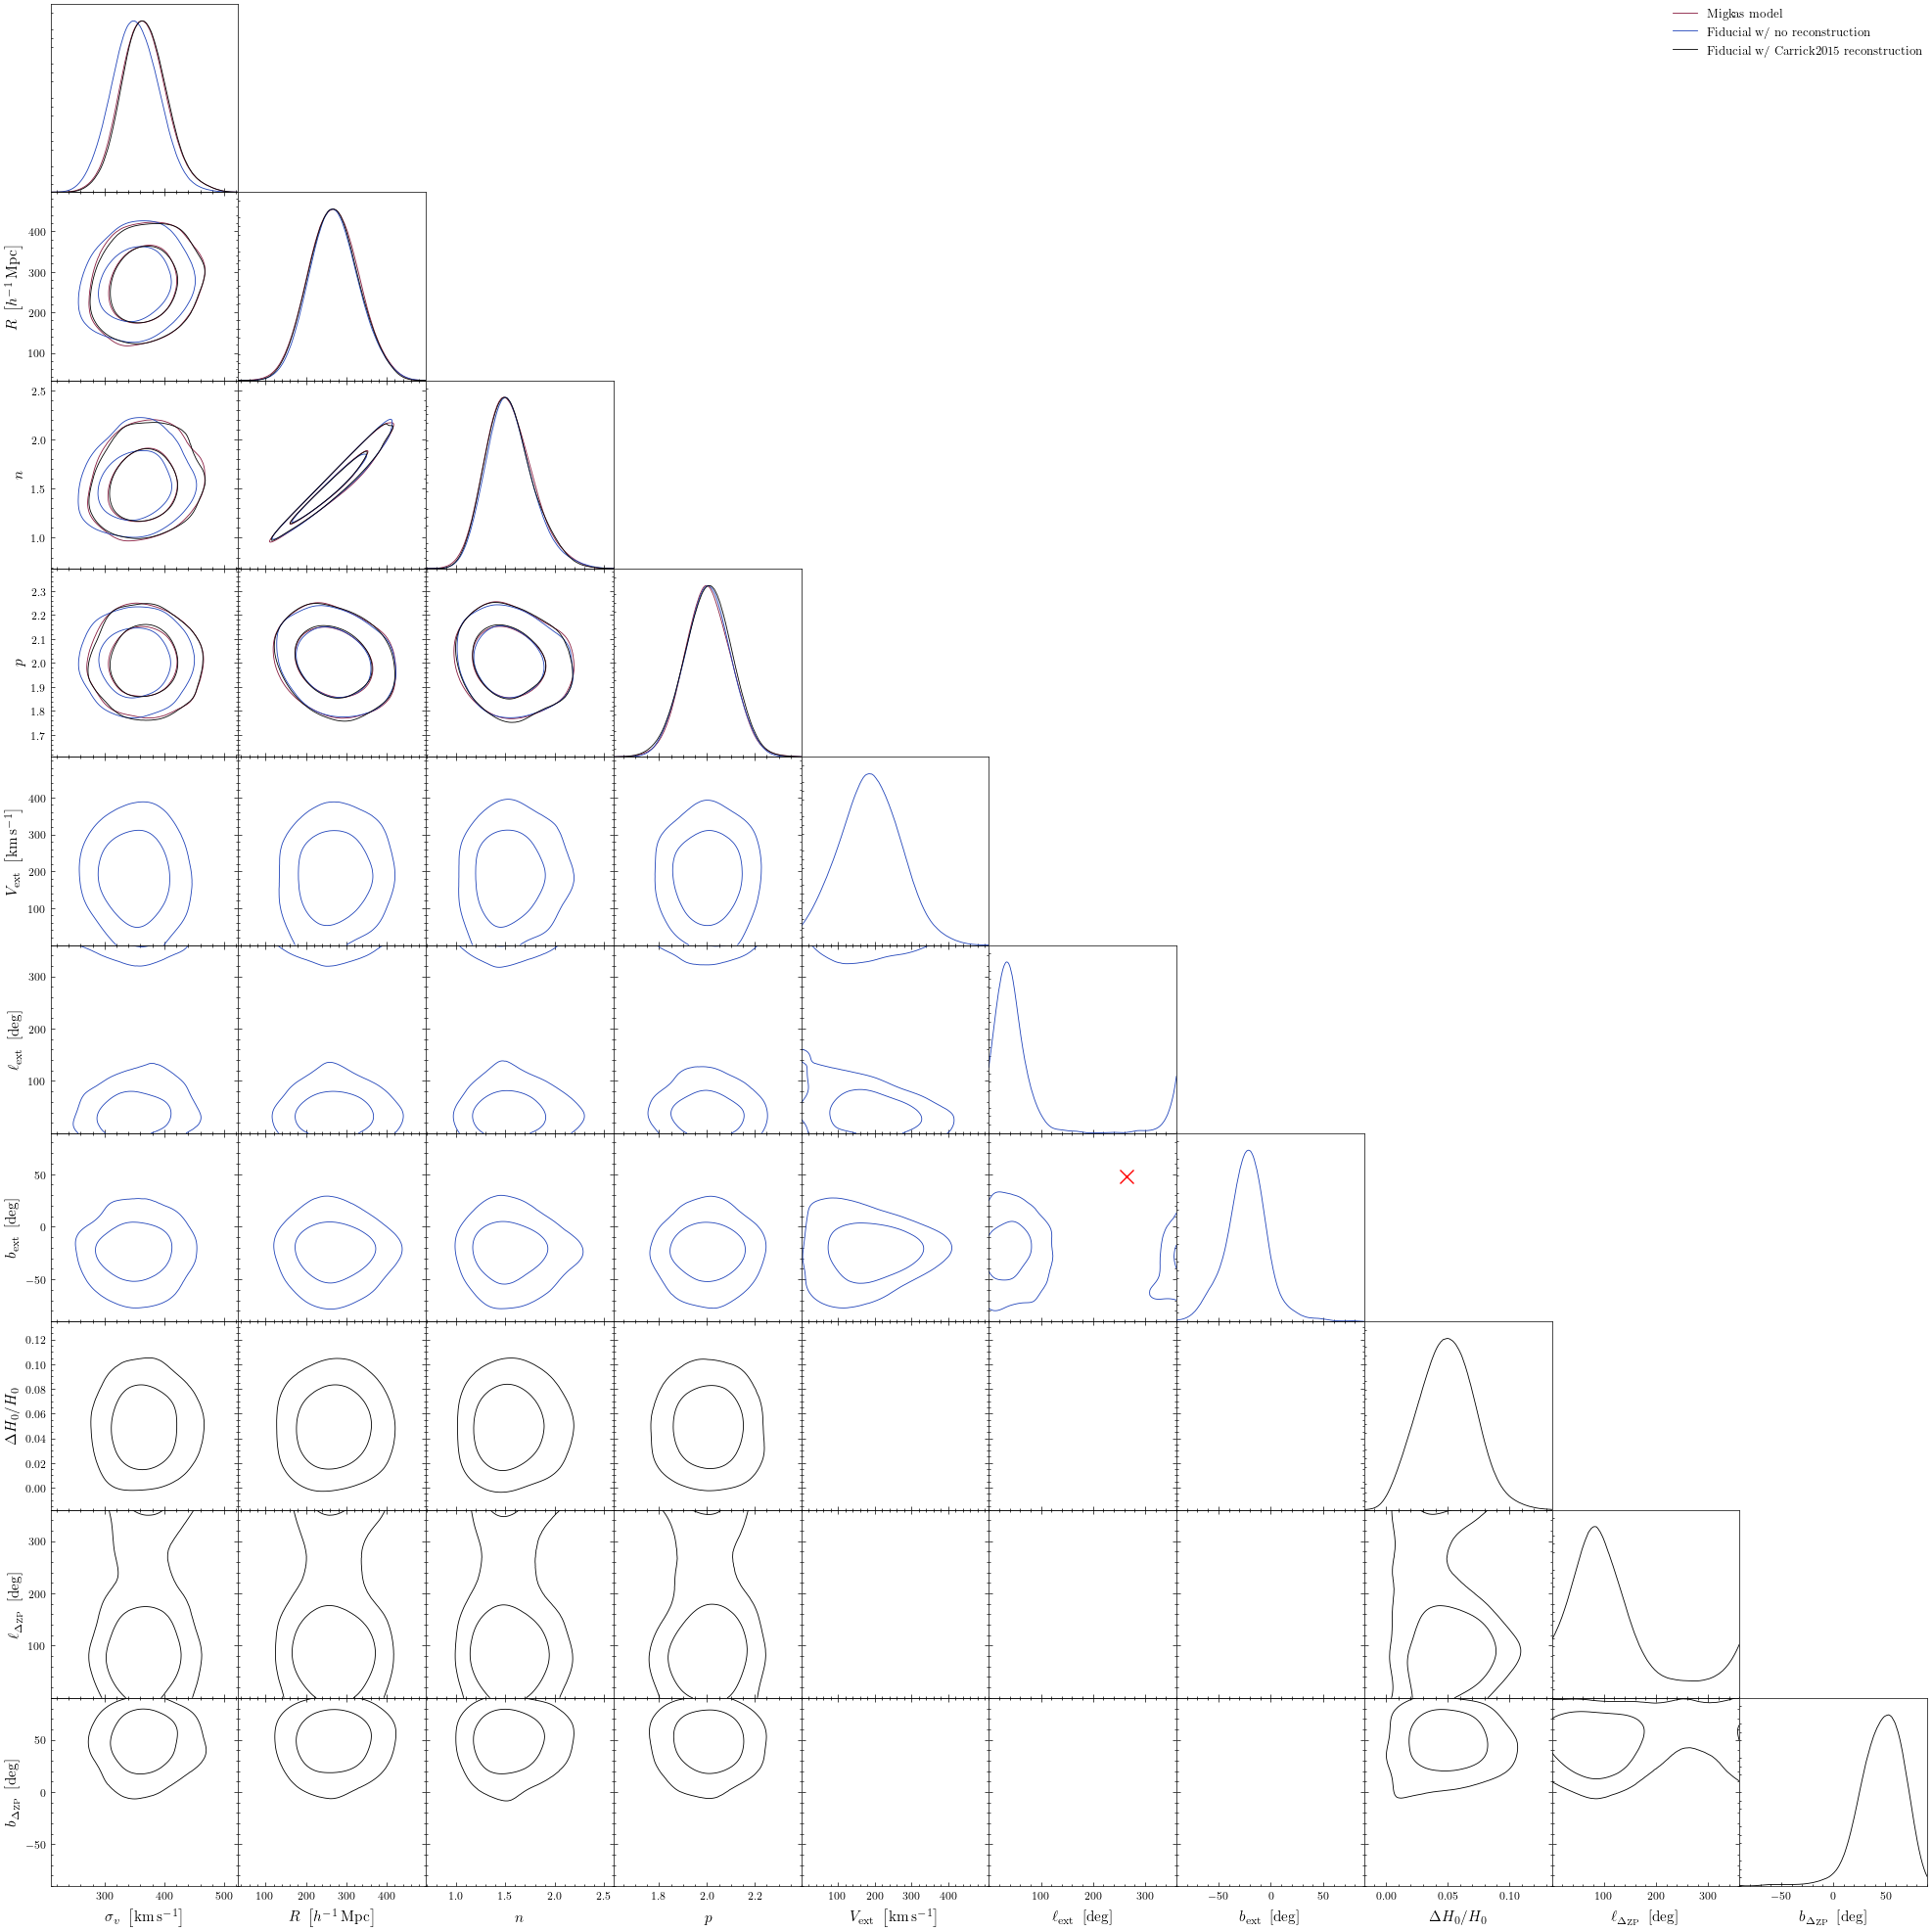

In [36]:



fnames = [
    f"{results_folder}/manticore_LTYT_noMNR_nodipA_hasY.hdf5",
    f"{results_folder}/manticore_LTYT_noMNR_nodipA_dipVext_hasY.hdf5",
    f"{results_folder}/manticore_LTYT_noMNR_dipA_hasY.hdf5",
    ]


keys = ['A_CL','B_CL','A2_CL', 'B2_CL', 'sigma', 'sigma2' 'rho12', 'sigma_v', 
        'R_dist_emp','n_dist_emp', 'p_dist_emp',
        'Vext_mag','Vext_ell', 'Vext_b',
        'dH_over_H_dipole', 'zeropoint_dipole_ell', 'zeropoint_dipole_b',
        ]

cols = [
    COLS[0],COLS[1],
    "k",
    ]

labels = [
    "Migkas model",
    "Fiducial w/ no reconstruction",
    "Fiducial w/ Carrick2015 reconstruction",
    ]

fnames = [join(root, f) for f in fnames]

points = {("Vext_ell", "Vext_b"): (264., 48.),}

print(fnames)
plot_corner_from_hdf5(
    fnames,
    labels=labels,
    cols=cols,
    filled=False,
    points=points,
    keys=keys,
    filename="/Users/yasin/Downloads/main_posterior.pdf",
    legend_fontsize=40,
    )

### Dipoles for different reconstructions

['/Users/yasin/code/CANDEL/results/short/Vext_LTYT_noMNR_nodipA_dipVext_hasY.hdf5', '/Users/yasin/code/CANDEL/results/short/carrick2015_LTYT_noMNR_nodipA_dipVext_hasY.hdf5', '/Users/yasin/code/CANDEL/results/short/manticore_LTYT_noMNR_nodipA_dipVext_hasY.hdf5']
Vext_LTYT_noMNR_nodipA_dipVext_hasY.hdf5: A_LT, A_YT, B_LT, B_YT, R_dist_emp, Vext, Vext_b, Vext_ell, Vext_mag, n_dist_emp, p_dist_emp, rho12, sigma_LT, sigma_YT, sigma_v
carrick2015_LTYT_noMNR_nodipA_dipVext_hasY.hdf5: A_LT, A_YT, B_LT, B_YT, R_dist_emp, Vext, Vext_b, Vext_ell, Vext_mag, b1, beta, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v
manticore_LTYT_noMNR_nodipA_dipVext_hasY.hdf5: A_LT, A_YT, B_LT, B_YT, R_dist_emp, Vext, Vext_b, Vext_ell, Vext_mag, alpha, beta, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v
Removed no burn in
Removed no burn in
Removed no burn in


/Users/yasin/code/CANDEL/candel/util.py:803: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


2025-11-11 14:46:59 [INFO] Saving GetDist triangle plot to: /Users/yasin/Dropbox/Apps/Overleaf/Cluster Anisotropies !/Figures/reconstruction_vext.pdf


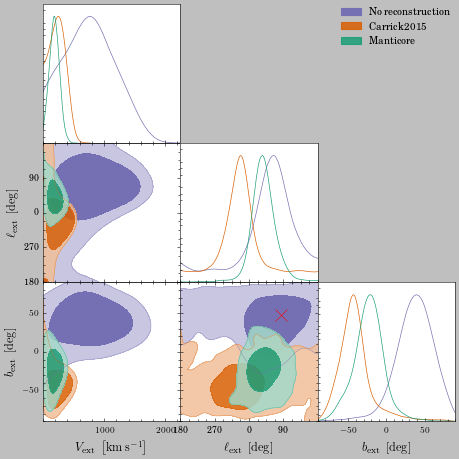

In [ ]:
### Figure (a)

fnames = [
        f"{results_folder}/Vext_LTYT_noMNR_nodipA_dipVext_hasY.hdf5",
    f"{results_folder}/carrick2015_LTYT_noMNR_nodipA_dipVext_hasY.hdf5",

    f"{results_folder}/manticore_LTYT_noMNR_nodipA_dipVext_hasY.hdf5",

    ]


keys = ['Vext_mag','Vext_ell', 'Vext_b']
        #'dH_over_H_dipole', 'zeropoint_dipole_ell', 'zeropoint_dipole_b',

cols = [
    COLS[0],COLS[1],
    COLS[2],
    ]

labels = [
    "No reconstruction",
    "Carrick2015",
    "Manticore",
    ]

fnames = [join(root, f) for f in fnames]

points = {("Vext_ell", "Vext_b"): (264., 48.),}

print(fnames)
to_save = figures_folder + "reconstruction_vext.pdf"

plot_corner_from_hdf5(
    fnames,
    labels=labels,
    cols=cols,
    filled=True,
    points=points,
    keys=keys,
    filename=to_save,
    legend_fontsize=40,
    apply_ell_offset=True,
    ell_zero=180.0
    )

['/Users/yasin/code/CANDEL/results/short/Vext_LTYT_noMNR_dipA_hasY.hdf5', '/Users/yasin/code/CANDEL/results/short/carrick2015_LTYT_noMNR_dipA_hasY.hdf5', '/Users/yasin/code/CANDEL/results/short/manticore_LTYT_noMNR_dipA_hasY.hdf5']
Vext_LTYT_noMNR_dipA_hasY.hdf5: A_LT, A_YT, B_LT, B_YT, R_dist_emp, dH_over_H_dipole, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v, zeropoint_dipole_b, zeropoint_dipole_ell
carrick2015_LTYT_noMNR_dipA_hasY.hdf5: A_LT, A_YT, B_LT, B_YT, R_dist_emp, b1, beta, dH_over_H_dipole, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v, zeropoint_dipole_b, zeropoint_dipole_ell
manticore_LTYT_noMNR_dipA_hasY.hdf5: A_LT, A_YT, B_LT, B_YT, R_dist_emp, alpha, beta, dH_over_H_dipole, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v, zeropoint_dipole_b, zeropoint_dipole_ell
Removed no burn in
Removed no burn in
Removed no burn in
2025-11-11 14:47:14 [INFO] Saving GetDist triangle plot to: /Users/yasin/Dropbox/Apps/Overleaf/Cluster Ani

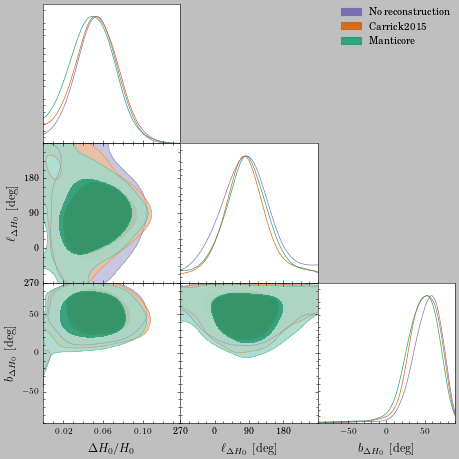

In [ ]:
### Figure (b)

fnames = [

        f"{results_folder}/Vext_LTYT_noMNR_dipA_hasY.hdf5",
    f"{results_folder}/carrick2015_LTYT_noMNR_dipA_hasY.hdf5",


    f"{results_folder}/manticore_LTYT_noMNR_dipA_hasY.hdf5",

    ]


keys = ['dH_over_H_dipole', 'zeropoint_dipole_ell', 'zeropoint_dipole_b']

cols = [
      COLS[0],
           COLS[1],
      COLS[2],
 
  

    ]

labels = [
        "No reconstruction",
        "Carrick2015",

        "Manticore",




    ]

fnames = [join(root, f) for f in fnames]

points = {("Vext_ell", "Vext_b"): (264., 48.),}

print(fnames)

to_save = figures_folder + "reconstruction_H0.pdf"
plot_corner_from_hdf5(
    fnames,
    labels=labels,
    cols=cols,
    filled=True,
    points=points,
    keys=keys,
    filename= to_save,
    legend_fontsize=40,
    ell_zero=-90.0,
    apply_ell_offset=True,
    )

### Scaling relation comparison

['/Users/yasin/code/CANDEL/results/short/Carrick2015_LT_noMNR_dipA.hdf5', '/Users/yasin/code/CANDEL/results/short/Carrick2015_YT_noMNR_dipA_hasY.hdf5', '/Users/yasin/code/CANDEL/results/short/Carrick2015_LTYT_noMNR_dipA_hasY.hdf5']
Carrick2015_LT_noMNR_dipA.hdf5: A_LT, B_LT, R_dist_emp, b1, beta, dH_over_H_dipole, n_dist_emp, p_dist_emp, sigma_int, sigma_v, zeropoint_dipole_b, zeropoint_dipole_ell
Carrick2015_YT_noMNR_dipA_hasY.hdf5: A_YT, B_YT, R_dist_emp, b1, beta, dH_over_H_dipole, n_dist_emp, p_dist_emp, sigma_int, sigma_v, zeropoint_dipole_b, zeropoint_dipole_ell
Carrick2015_LTYT_noMNR_dipA_hasY.hdf5: A_LT, A_YT, B_LT, B_YT, R_dist_emp, b1, beta, dH_over_H_dipole, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v, zeropoint_dipole_b, zeropoint_dipole_ell
Removed no burn in
Removed no burn in
Removed no burn in
2025-11-11 14:47:34 [INFO] Saving GetDist triangle plot to: /Users/yasin/Dropbox/Apps/Overleaf/Cluster Anisotropies !/Figures/LT_YT_LTYT_dipA.pdf


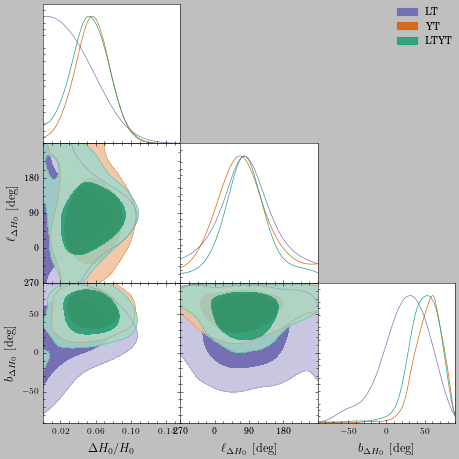

In [214]:

fnames = [
    f"{results_folder}/Carrick2015_LT_noMNR_dipA.hdf5",
    f"{results_folder}/Carrick2015_YT_noMNR_dipA_hasY.hdf5",
    f"{results_folder}/Carrick2015_LTYT_noMNR_dipA_hasY.hdf5",
]

keys = ['dH_over_H_dipole', 'zeropoint_dipole_ell', 'zeropoint_dipole_b']

cols = [
    COLS[0],
    COLS[1],
    COLS[2],
]

labels = [
    "LT",
    "YT",
    "LTYT",
]

fnames = [join(root, f) for f in fnames]

print(fnames)

to_save = figures_folder + "LT_YT_LTYT_dipA.pdf"
plot_corner_from_hdf5(
    fnames,
    labels=labels,
    cols=cols,
    filled=True,
    keys=keys,
    filename=to_save,
    legend_fontsize=40,
    apply_ell_offset=True,
    ell_zero=-90.0,
)


### Sigma_v plot

Removed no burn in
Removed no burn in
Removed no burn in


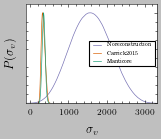

In [215]:
from getdist import plots, MCSamples
from candel import read_samples

fnames = [
    f"{results_folder}/Vext_LTYT_noMNR_nodipA_dipVext_hasY.hdf5",
    f"{results_folder}/carrick2015_LTYT_noMNR_nodipA_dipVext_hasY.hdf5",
    f"{results_folder}/manticore_LTYT_noMNR_nodipA_dipVext_hasY.hdf5",
]
labels = ["No reconstruction", "Carrick2015", "Manticore"]
cols = [COLS[0], COLS[1], COLS[2]]

sigma_samples = []
for f in fnames:
    arr = read_samples(root, f, keys="sigma_v")
    sigma_samples.append(MCSamples(
        samples=np.asarray(arr).reshape(-1, 1),
        names=["sigma_v"],
        labels=[r"\sigma_v"],
    ))

settings = plots.GetDistPlotSettings()
settings.alpha_filled_add = -0.25  # matches our corner plot tweak
g = plots.get_subplot_plotter(settings=settings)
g.plot_1d(
    sigma_samples,
    param="sigma_v",
    colors=cols,
    legend_labels=labels,
)
g.add_legend(legend_labels=labels, legend_loc='center right', fontsize=5, frameon=False)

ax = g.subplots[0][0]
ax.set_ylabel(r"$P(\sigma_v)$", fontsize=settings.axes_fontsize)
to_save = figures_folder + "sigma_v.pdf"
g.export(to_save)


### Migkas comparison plot

['/Users/yasin/code/CANDEL/results/Migkas_comparison/Migkas_Clusters_noMNR_linear_LT.hdf5', '/Users/yasin/code/CANDEL/results/Migkas_comparison/Vext_Clusters_noMNR_linear_LT.hdf5', '/Users/yasin/code/CANDEL/results/Migkas_comparison/precomputed_los_Carrick2015_Clusters_noMNR_linear_LT.hdf5']
Migkas_Clusters_noMNR_linear_LT.hdf5: A_CL, B_CL, Vext, Vext_b, Vext_ell, Vext_mag, sigma_int
Vext_Clusters_noMNR_linear_LT.hdf5: A_CL, B_CL, R_dist_emp, Vext, Vext_b, Vext_ell, Vext_mag, n_dist_emp, p_dist_emp, sigma_int, sigma_v
precomputed_los_Carrick2015_Clusters_noMNR_linear_LT.hdf5: A_CL, B_CL, R_dist_emp, Vext, Vext_b, Vext_ell, Vext_mag, b1, beta, n_dist_emp, p_dist_emp, sigma_int, sigma_v
Removed no burn in
Removed no burn in
Removed no burn in


/Users/yasin/code/CANDEL/candel/util.py:756: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


2025-10-24 18:26:16 [INFO] Saving GetDist triangle plot to: /Users/yasin/Downloads/migkas_comparison.pdf


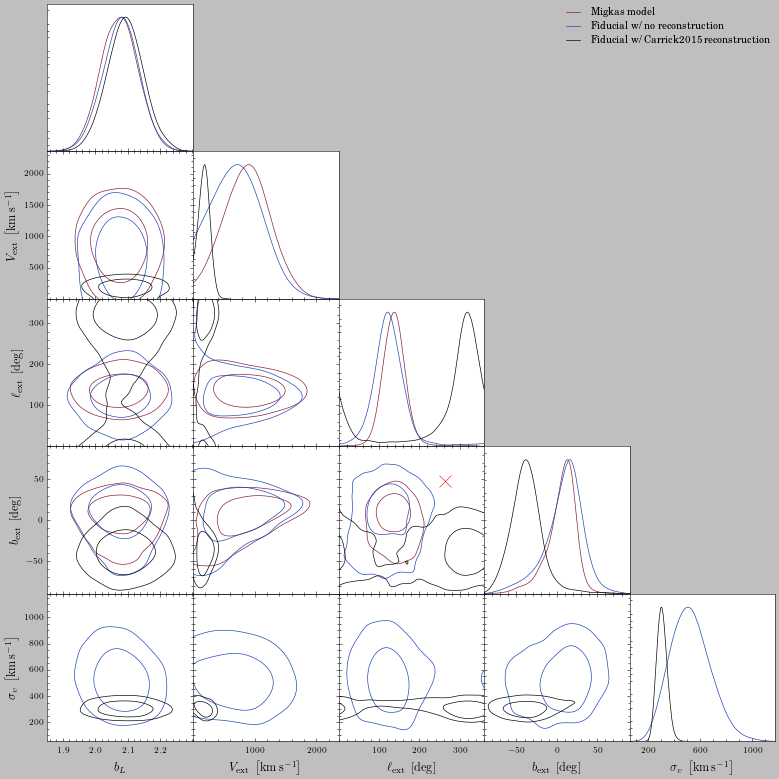

In [ ]:

fnames = [
    "Migkas_comparison/Migkas_Clusters_noMNR_linear_LT.hdf5",
    "Migkas_comparison/Vext_Clusters_noMNR_linear_LT.hdf5",
    "Migkas_comparison/precomputed_los_Carrick2015_Clusters_noMNR_linear_LT.hdf5"
    ]

cols = [
    COLS[0],COLS[1],
    "k",
    ]

labels = [
    "Migkas model",
    "Fiducial w/ no reconstruction",
    "Fiducial w/ Carrick2015 reconstruction",
    ]

fnames = [join(root, f) for f in fnames]

keys = ['B_CL','Vext_mag','Vext_ell', 'Vext_b', 'sigma_v']

points = {("Vext_ell", "Vext_b"): (264., 48.),}

print(fnames)
plot_corner_from_hdf5(
    fnames,
    labels=labels,
    cols=cols,
    filled=False,
    points=points,
    keys=keys,
    filename="/Users/yasin/Downloads/migkas_comparison.pdf",
    )

### MNR vs noMNR comparison

['/Users/yasin/code/CANDEL/results/friday/Carrick2015_Clusters_MNR_LTYT_dipVext_hasY.hdf5', '/Users/yasin/code/CANDEL/results/friday/Carrick2015_Clusters_noMNR_LTYT_dipVext_hasY.hdf5']
Carrick2015_Clusters_MNR_LTYT_dipVext_hasY.hdf5: A2_CL, A_CL, B2_CL, B_CL, R_dist_emp, Vext, Vext_b, Vext_ell, Vext_mag, alpha, beta, logT_latent, logT_prior_mean, logT_prior_std, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v
Carrick2015_Clusters_noMNR_LTYT_dipVext_hasY.hdf5: A2_CL, A_CL, B2_CL, B_CL, R_dist_emp, Vext, Vext_b, Vext_ell, Vext_mag, alpha, beta, n_dist_emp, p_dist_emp, rho12, sigma_int, sigma_int2, sigma_v
Removed no burn in
Removed no burn in


/Users/yasin/code/CANDEL/candel/util.py:756: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


2025-10-24 18:24:46 [INFO] Saving GetDist triangle plot to: /Users/yasin/Downloads/migkas_comparison.pdf


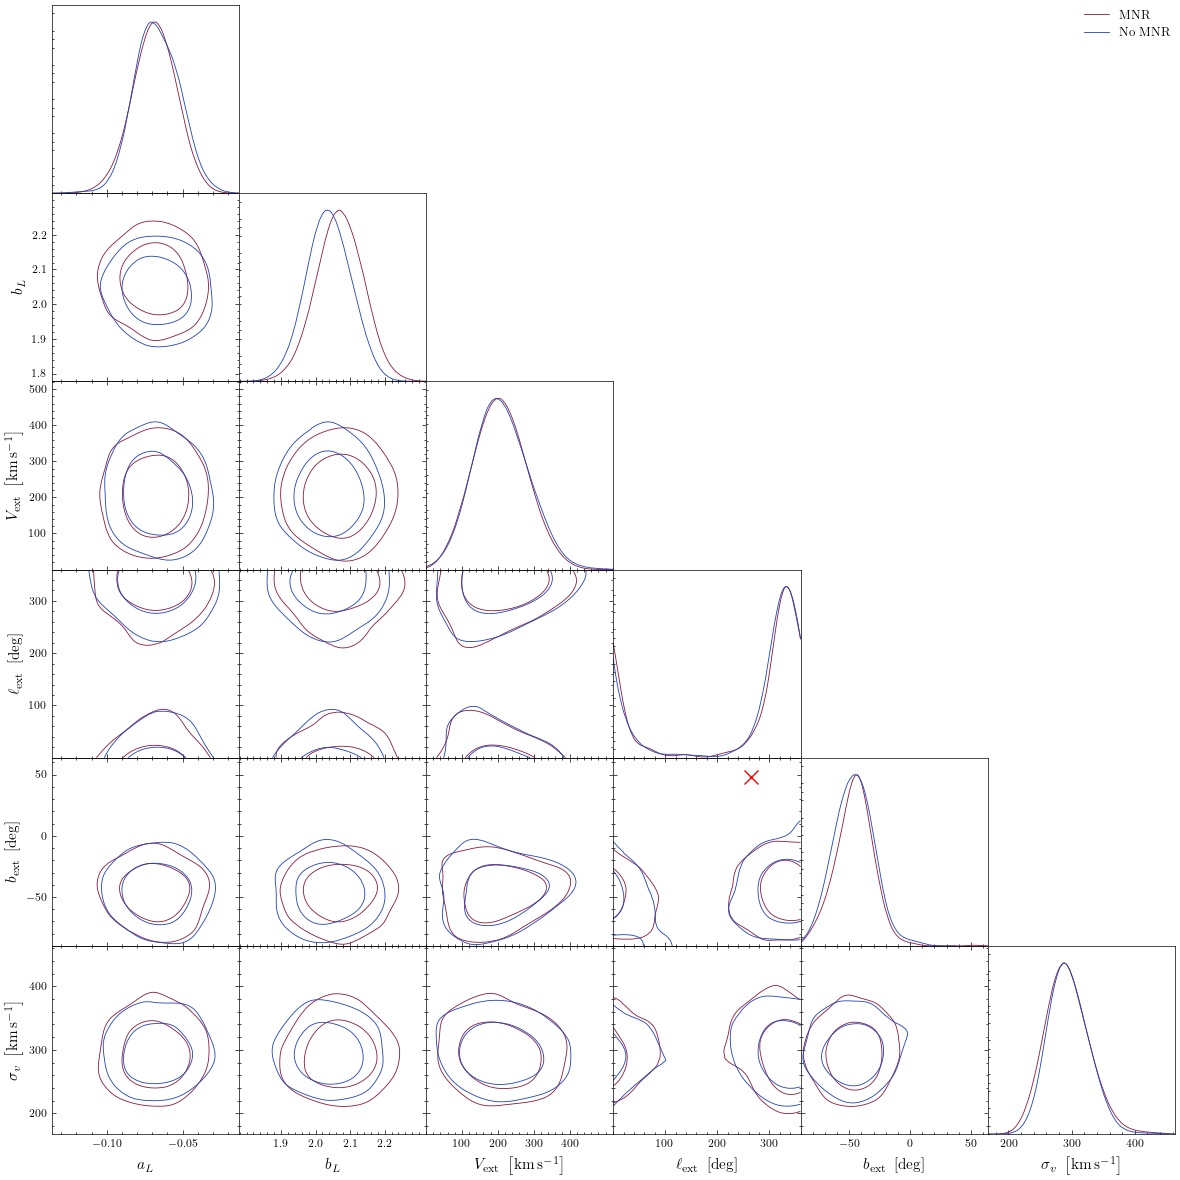

In [ ]:

fnames = [
    f"{results_folder}/Carrick2015_Clusters_MNR_LTYT_dipVext_hasY.hdf5",
    f"{results_folder}/Carrick2015_Clusters_noMNR_LTYT_dipVext_hasY.hdf5",
    ]

cols = [
    COLS[0],COLS[1],
    "k",
    ]

labels = [
    "MNR",
    "No MNR",
    ]

fnames = [join(root, f) for f in fnames]

keys = ['A_CL','B_CL','Vext_mag','Vext_ell', 'Vext_b', 'sigma_v']

points = {("Vext_ell", "Vext_b"): (264., 48.),}

print(fnames)
plot_corner_from_hdf5(
    fnames,
    labels=labels,
    cols=cols,
    filled=False,
    points=points,
    keys=keys,
    filename="/Users/yasin/Downloads/migkas_comparison.pdf",
    )